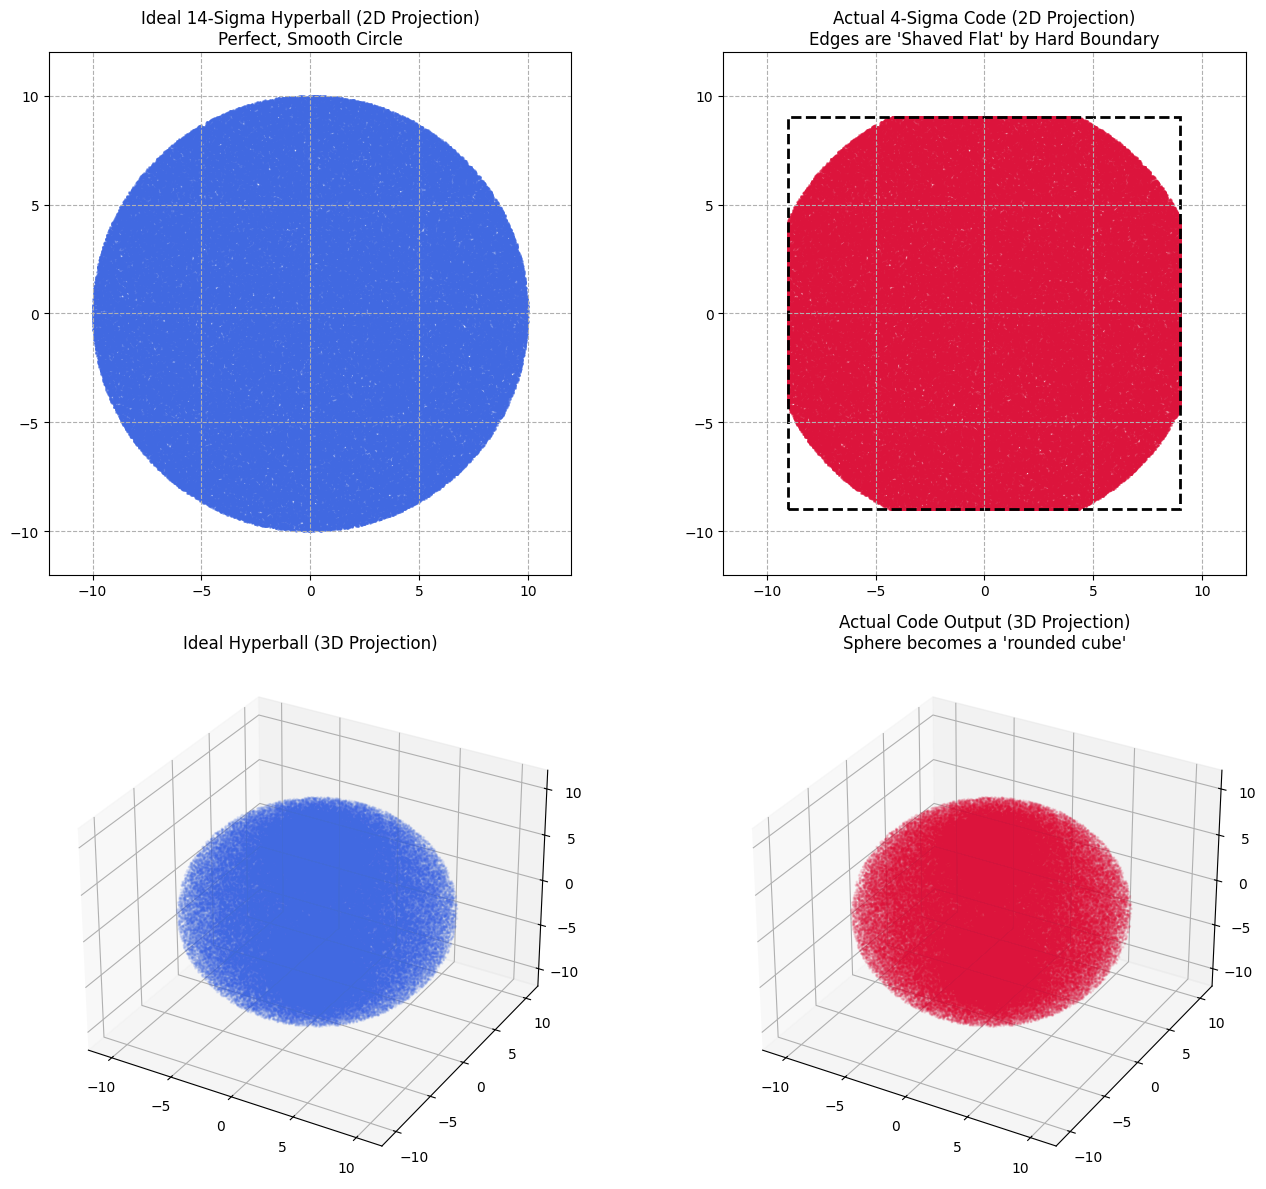

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_hyperball_truncation():
    # 参数设置
    N_samples = 200000
    R = 10.0  # 超球的理论目标半径
    
    # 为了在 2D/3D 中可视化高维的 4-sigma 截断效应
    # 我们设置一个人工的单维度硬边界 (模拟 4-sigma 盒子)
    # 在真实高维中，这个截断值相比于半径会非常小；这里用 0.75R 以获得最佳可视化效果
    truncation_bound = 0.9 * R 

    # ==========================================
    # 1. 生成理想的完美超球（这里降维到 2D 圆和 3D 球）
    # ==========================================
    # 2D 理想分布
    angles_2d = np.random.uniform(0, 2*np.pi, N_samples)
    radii_2d = np.sqrt(np.random.uniform(0, 1, N_samples)) * R
    x_ideal_2d = radii_2d * np.cos(angles_2d)
    y_ideal_2d = radii_2d * np.sin(angles_2d)

    # 3D 理想分布
    phi = np.random.uniform(0, np.pi, N_samples)
    theta = np.random.uniform(0, 2*np.pi, N_samples)
    radii_3d = np.cbrt(np.random.uniform(0, 1, N_samples)) * R
    x_ideal_3d = radii_3d * np.sin(phi) * np.cos(theta)
    y_ideal_3d = radii_3d * np.sin(phi) * np.sin(theta)
    z_ideal_3d = radii_3d * np.cos(phi)

    # ==========================================
    # 2. 模拟被 4-sigma 截断的代码实际采样结果
    # ==========================================
    # 所有的坐标都不能超过 truncation_bound 的绝对硬边界
    x_trunc_2d = np.clip(x_ideal_2d, -truncation_bound, truncation_bound)
    y_trunc_2d = np.clip(y_ideal_2d, -truncation_bound, truncation_bound)

    x_trunc_3d = np.clip(x_ideal_3d, -truncation_bound, truncation_bound)
    y_trunc_3d = np.clip(y_ideal_3d, -truncation_bound, truncation_bound)
    z_trunc_3d = np.clip(z_ideal_3d, -truncation_bound, truncation_bound)

    # ==========================================
    # 3. 开始绘图
    # ==========================================
    fig = plt.figure(figsize=(14, 12))

    # --- 2D 理想对比 ---
    ax1 = fig.add_subplot(221)
    ax1.scatter(x_ideal_2d, y_ideal_2d, s=1, color='royalblue', alpha=0.5)
    ax1.set_title("Ideal 14-Sigma Hyperball (2D Projection)\nPerfect, Smooth Circle", fontsize=12)
    ax1.set_xlim(-1.2*R, 1.2*R); ax1.set_ylim(-1.2*R, 1.2*R)
    ax1.set_aspect('equal')
    ax1.grid(True, linestyle='--')

    # --- 2D 实际代码截断对比 ---
    ax2 = fig.add_subplot(222)
    ax2.scatter(x_trunc_2d, y_trunc_2d, s=1, color='crimson', alpha=0.5)
    # 画出由于 4-sigma 带来的致命“硬边界盒子”
    rect = plt.Rectangle((-truncation_bound, -truncation_bound), 2*truncation_bound, 2*truncation_bound, 
                         fill=False, color='black', linewidth=2, linestyle='dashed')
    ax2.add_patch(rect)
    ax2.set_title("Actual 4-Sigma Code (2D Projection)\nEdges are 'Shaved Flat' by Hard Boundary", fontsize=12)
    ax2.set_xlim(-1.2*R, 1.2*R); ax2.set_ylim(-1.2*R, 1.2*R)
    ax2.set_aspect('equal')
    ax2.grid(True, linestyle='--')

    # --- 3D 理想对比 ---
    ax3 = fig.add_subplot(223, projection='3d')
    ax3.scatter(x_ideal_3d, y_ideal_3d, z_ideal_3d, s=1, color='royalblue', alpha=0.1)
    ax3.set_title("Ideal Hyperball (3D Projection)", fontsize=12)
    ax3.set_xlim(-1.2*R, 1.2*R); ax3.set_ylim(-1.2*R, 1.2*R); ax3.set_zlim(-1.2*R, 1.2*R)

    # --- 3D 实际代码截断对比 ---
    ax4 = fig.add_subplot(224, projection='3d')
    ax4.scatter(x_trunc_3d, y_trunc_3d, z_trunc_3d, s=1, color='crimson', alpha=0.1)
    ax4.set_title("Actual Code Output (3D Projection)\nSphere becomes a 'rounded cube'", fontsize=12)
    ax4.set_xlim(-1.2*R, 1.2*R); ax4.set_ylim(-1.2*R, 1.2*R); ax4.set_zlim(-1.2*R, 1.2*R)

    plt.tight_layout()
    plt.show()

plot_hyperball_truncation()

Starting simulation for 10000000 samples in 256 dimensions...
Processing in batches of 10000 to save memory.

=== Truncation Statistics Report ===
Total simulated high-dim vectors : 10,000,000
Vectors corrupted by 14σ bound   : 0 (Theory expectation -> 0)
Vectors corrupted by  4σ bound   : 161,774 (Code vulnerability!)
Difference in corrupted samples  : 161,774



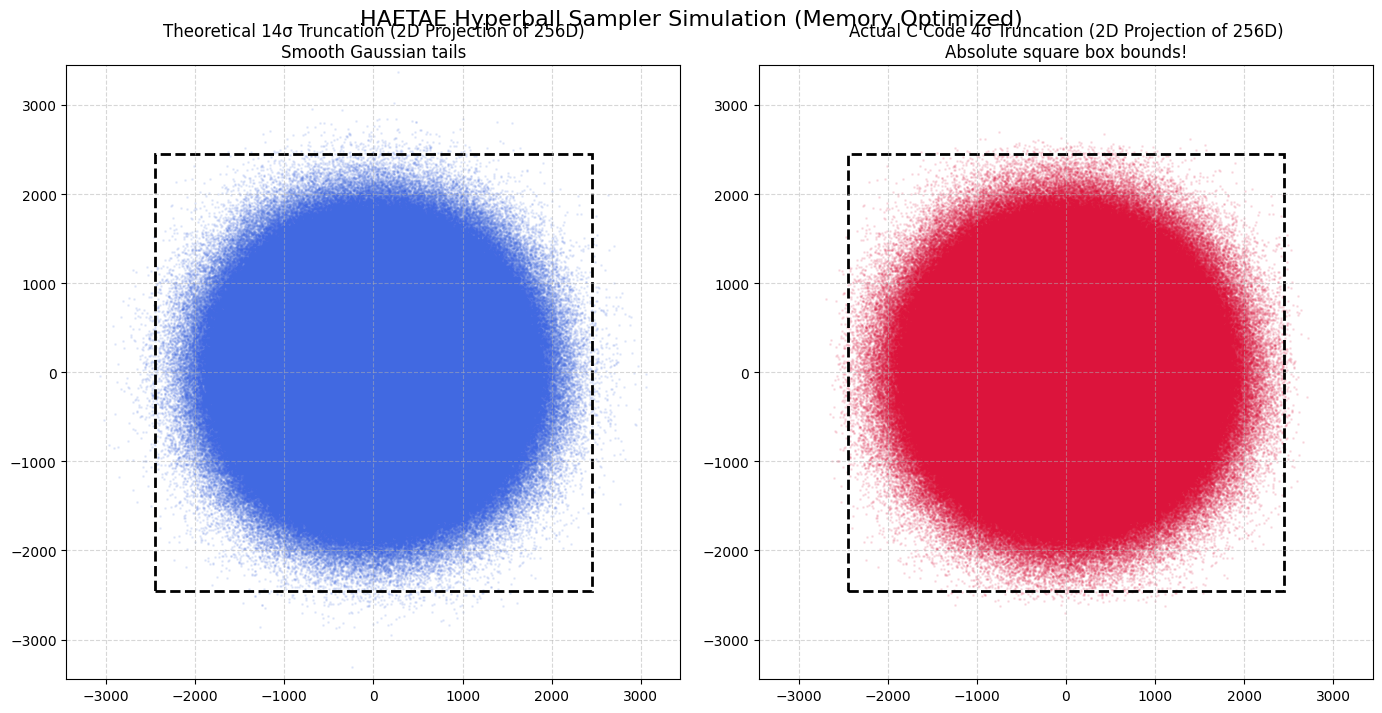

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def optimized_haetae_simulation():
    # ==========================================
    # 1. 优化后的参数设置
    # ==========================================
    N_samples = 10000000          # 模拟 1000 万次独立签名
    batch_size = 10000          # 内存优化：分批处理，每次 1 万条
    
    # 降维处理：256维足以体现高维超球的“范数集中效应”，且计算极快
    D = 256                     
    D_sample = D + 2            # 模拟 C 代码中丢弃的 2 个计算范数用的额外维度
    
    sigma = 1.0                 # 基础高斯标准差
    R = 9846.02                 # HAETAE-120 目标超球半径 B

    # 用于保存二维投影结果的列表（极大节省内存，因为抛弃了其他维度）
    Y_14_2d_list = []
    Y_4_2d_list = []
    
    # 统计数据：记录有多少个高维向量（即每次签名）受到了边界截断的影响
    vectors_truncated_14 = 0
    vectors_truncated_4 = 0

    print(f"Starting simulation for {N_samples} samples in {D} dimensions...")
    print(f"Processing in batches of {batch_size} to save memory.\n")

    # ==========================================
    # 2. 内存友好的分批处理循环
    # ==========================================
    for i in range(0, N_samples, batch_size):
        # 仅生成当前批次的理想高斯数据
        X_ideal = np.random.randn(batch_size, D_sample) * sigma
        
        # --- 统计被截断的向量数量 ---
        # 只要这个向量的任意一个维度超过了边界，它就被认为是“受损的”
        out_of_14_bound = np.any(np.abs(X_ideal) > 14 * sigma, axis=1)
        out_of_4_bound  = np.any(np.abs(X_ideal) > 4 * sigma, axis=1)
        
        vectors_truncated_14 += np.sum(out_of_14_bound)
        vectors_truncated_4  += np.sum(out_of_4_bound)

        # --- 执行物理截断 ---
        X_14 = np.clip(X_ideal, -14 * sigma, 14 * sigma)
        X_4  = np.clip(X_ideal,  -4 * sigma,  4 * sigma)

        # --- 模拟 C代码逻辑：计算范数、归一化缩放 ---
        # 注意 keepdims=True 方便广播相除
        norm_14 = np.linalg.norm(X_14, axis=1, keepdims=True)
        norm_4  = np.linalg.norm(X_4,  axis=1, keepdims=True)

        # 归一化，乘以目标半径 R。我们只需要前两个维度用于画图！
        Y_14_batch = (X_14[:, :2] / norm_14) * R
        Y_4_batch  = (X_4[:,  :2] / norm_4)  * R

        Y_14_2d_list.append(Y_14_batch)
        Y_4_2d_list.append(Y_4_batch)
        
    # 合并所有批次的 2D 数据
    Y_14_2d = np.vstack(Y_14_2d_list)
    Y_4_2d  = np.vstack(Y_4_2d_list)

    # ==========================================
    # 3. 打印统计报告
    # ==========================================
    print("=== Truncation Statistics Report ===")
    print(f"Total simulated high-dim vectors : {N_samples:,}")
    print(f"Vectors corrupted by 14σ bound   : {vectors_truncated_14:,} (Theory expectation -> 0)")
    print(f"Vectors corrupted by  4σ bound   : {vectors_truncated_4:,} (Code vulnerability!)")
    difference = vectors_truncated_4 - vectors_truncated_14
    print(f"Difference in corrupted samples  : {difference:,}\n")

    # ==========================================
    # 4. 计算理论的几何硬边界并画图
    # ==========================================
    # 大数定理：258维高斯向量的预期范数集中在 sqrt(258)*sigma 附近
    expected_norm = np.sqrt(D_sample) * sigma
    bound_14 = (14 * sigma) / expected_norm * R
    bound_4  = ( 4 * sigma) / expected_norm * R

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

    # 子图 1: 理论安全的 14倍标准差截断
    ax1.scatter(Y_14_2d[:, 0], Y_14_2d[:, 1], s=1, alpha=0.1, color='royalblue')
    ax1.set_xlim(-0.35 * R, 0.35 * R)
    ax1.set_ylim(-0.35 * R, 0.35 * R)
    ax1.set_title(f"Theoretical 14σ Truncation (2D Projection of {D}D)\nSmooth Gaussian tails", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.set_aspect('equal')
    rect14 = plt.Rectangle((-bound_4, -bound_4), 2*bound_4, 2*bound_4, fill=False, color='black', linestyle='dashed', linewidth=2)
    ax1.add_patch(rect14)

    # 子图 2: 实际 C 代码的 4倍标准差截断 (漏洞所在)
    ax2.scatter(Y_4_2d[:, 0], Y_4_2d[:, 1], s=1, alpha=0.1, color='crimson')
    ax2.set_xlim(-0.35 * R, 0.35 * R)
    ax2.set_ylim(-0.35 * R, 0.35 * R)
    ax2.set_title(f"Actual C Code 4σ Truncation (2D Projection of {D}D)\nAbsolute square box bounds!", fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_aspect('equal')
    rect4 = plt.Rectangle((-bound_4, -bound_4), 2*bound_4, 2*bound_4, fill=False, color='black', linestyle='dashed', linewidth=2)
    ax2.add_patch(rect4)

    plt.suptitle("HAETAE Hyperball Sampler Simulation (Memory Optimized)", fontsize=16)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    optimized_haetae_simulation()